# **the next code does:**

- Loads the **final trained ResNet18** and the reserved Neysan test images.
- Checks that Neysan images were **never used during training** and that all files are valid.
- Confirms Neysan images should be evaluated as the **`vanet`** class.
- Sets the **0.8 confidence threshold** for deciding which predictions may need human checking.

In [1]:
from pathlib import Path
import pandas as pd
import torch

PROJECT_ROOT = Path(
    r"D:\Maktab_Sharif_Projects\traffic-vehicle-classification"
)

MANIFEST_DIR = (
    PROJECT_ROOT / "data" / "neysan_experiment" / "manifests"
)
EXPERIMENT_DIR = PROJECT_ROOT / "outputs" / "neysan_experiment"

CHECKPOINT_PATH = (
    EXPERIMENT_DIR / "trainval_refit"
    / "resnet18_neysan_trainval_final.pt"
)

EVALUATION_DIR = EXPERIMENT_DIR / "neysan_test"
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=True,
)

config = checkpoint["config"]
class_to_idx = checkpoint["class_to_idx"]
classes = sorted(class_to_idx, key=class_to_idx.get)

neysan_df = pd.read_csv(MANIFEST_DIR / "neysan_test.csv")

assert checkpoint["epoch"] == config["epochs"] == 10
assert not neysan_df.empty
assert neysan_df["path"].is_unique
assert neysan_df["sha256"].is_unique
assert set(neysan_df["label"]) == {"neysan"}
assert set(neysan_df["expected_class"]) == {"vanet"}
assert "neysan" not in class_to_idx
assert "vanet" in class_to_idx

assert set(neysan_df["sha256"]).isdisjoint(
    checkpoint["training_sha256"]
)

missing_paths = [
    path for path in neysan_df["path"]
    if not Path(path).is_file()
]
assert not missing_paths, f"Missing images: {missing_paths[:5]}"

CONFIDENCE_THRESHOLD = float(config["human_check_threshold"])
assert CONFIDENCE_THRESHOLD == 0.8

print("Device:", DEVICE)
print("Checkpoint:", CHECKPOINT_PATH.name)
print("Final refit epoch:", checkpoint["epoch"])
print("Neysan test images:", len(neysan_df))
print("Expected class: vanet")
print("Exact overlap with refit training: 0")
print("Missing image paths:", len(missing_paths))
print("Human-check threshold:", CONFIDENCE_THRESHOLD)

Device: cpu
Checkpoint: resnet18_neysan_trainval_final.pt
Final refit epoch: 10
Neysan test images: 243
Expected class: vanet
Exact overlap with refit training: 0
Missing image paths: 0
Human-check threshold: 0.8


# **the next code does:**

- Prepares the Neysan test images using the same **resize and normalization** as training.
- Creates a test dataset where every Neysan image has the expected label **`vanet`**.
- Loads the **final trained ResNet18** and prepares it for evaluation.
- Checks that the test images and labels are valid before testing the model.

In [2]:
from PIL import Image, ImageOps
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms


class ResizeWithPadding:
    def __init__(self, size, color):
        self.size = size
        self.color = tuple(color)

    def __call__(self, image):
        resized = ImageOps.contain(
            image,
            (self.size, self.size),
            method=Image.Resampling.BILINEAR,
        )

        canvas = Image.new(
            "RGB", (self.size, self.size), self.color
        )
        canvas.paste(
            resized,
            (
                (self.size - resized.width) // 2,
                (self.size - resized.height) // 2,
            ),
        )
        return canvas


test_transform = transforms.Compose([
    ResizeWithPadding(
        config["image_size"],
        config["padding_color"],
    ),
    transforms.ToTensor(),
    transforms.Normalize(config["mean"], config["std"]),
])


class NeysanDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["path"]) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            tensor = self.transform(image)

        # Neysan's expected output is the existing Vanet class.
        label = class_to_idx[row["expected_class"]]
        return tensor, label


test_dataset = NeysanDataset(neysan_df, test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=0,
)

model = models.resnet18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=config["dropout"]),
    nn.Linear(model.fc.in_features, len(classes)),
)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE).eval()

images, labels = next(iter(test_loader))

assert torch.isfinite(images).all()
assert (labels == class_to_idx["vanet"]).all()

print("Model loaded from the final checkpoint.")
print("Test images:", len(test_dataset))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image values finite:", torch.isfinite(images).all().item())
print("All expected labels: vanet")
print("Test loader ready.")

Model loaded from the final checkpoint.
Test images: 243
Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Image values finite: True
All expected labels: vanet
Test loader ready.


# **the next code does:**

- Runs the final model on all **Neysan test images** and records its predicted class and confidence.
- Compares predictions with the expected **`vanet`** label and calculates accuracy, precision, recall, and F1.
- Marks predictions with confidence **below 80%** for human checking.
- Saves predictions, errors, classification metrics, and the confusion matrix to the evaluation folder.

In [3]:
import json
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

true_labels = []
predicted_labels = []
all_scores = []

model.eval()

with torch.inference_mode():
    for images, labels in test_loader:
        logits = model(images.to(DEVICE))

        if not torch.isfinite(logits).all():
            raise RuntimeError("Model produced non-finite scores.")

        predicted_labels.extend(logits.argmax(1).cpu().tolist())
        true_labels.extend(labels.tolist())

        # Sigmoid scores match the BCE training objective.
        all_scores.extend(torch.sigmoid(logits).cpu().tolist())

true_labels = np.asarray(true_labels)
predicted_labels = np.asarray(predicted_labels)
all_scores = np.asarray(all_scores)

assert len(predicted_labels) == len(neysan_df)

confidence = all_scores[
    np.arange(len(predicted_labels)), predicted_labels
]

predictions_df = neysan_df.copy().reset_index(drop=True)
predictions_df["predicted_class"] = [
    classes[index] for index in predicted_labels
]
predictions_df["confidence"] = confidence
predictions_df["confidence_percent"] = confidence * 100
predictions_df["correct"] = true_labels == predicted_labels
predictions_df["needs_human_check"] = (
    confidence < CONFIDENCE_THRESHOLD
)

for index, name in enumerate(classes):
    predictions_df[f"sigmoid_score_{name}"] = all_scores[:, index]

vanet_id = class_to_idx["vanet"]

vanet_precision, vanet_recall, vanet_f1, vanet_support = (
    precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=[vanet_id],
        average=None,
        zero_division=0,
    )
)

metrics = {
    "checkpoint": CHECKPOINT_PATH.name,
    "test_images": int(len(predictions_df)),
    "correct": int(predictions_df["correct"].sum()),
    "errors": int((~predictions_df["correct"]).sum()),
    "neysan_as_vanet_accuracy": float(
        accuracy_score(true_labels, predicted_labels)
    ),
    "vanet_recall_on_neysan": float(vanet_recall[0]),
    "vanet_precision_on_neysan_only": float(vanet_precision[0]),
    "vanet_f1_on_neysan_only": float(vanet_f1[0]),
    "confidence_method": "uncalibrated_sigmoid_score",
    "human_check_threshold": CONFIDENCE_THRESHOLD,
    "below_threshold_images": int(
        predictions_df["needs_human_check"].sum()
    ),
    "evaluation_scope": (
        "Neysan-only test; expected class is vanet. "
        "All images included regardless of confidence."
    ),
}

report = classification_report(
    true_labels,
    predicted_labels,
    labels=list(range(len(classes))),
    target_names=classes,
    output_dict=True,
    zero_division=0,
)

matrix = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=list(range(len(classes))),
)

predictions_df.to_csv(
    EVALUATION_DIR / "predictions.csv", index=False
)
predictions_df.loc[~predictions_df["correct"]].to_csv(
    EVALUATION_DIR / "errors.csv", index=False
)
pd.DataFrame(report).T.to_csv(
    EVALUATION_DIR / "classification_report.csv"
)
pd.DataFrame(matrix, index=classes, columns=classes).to_csv(
    EVALUATION_DIR / "confusion_matrix.csv",
    index_label="expected_class",
)

with (EVALUATION_DIR / "metrics.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(metrics, file, indent=2)

print(
    "Neysan predicted as Vanet:",
    f"{metrics['neysan_as_vanet_accuracy']:.2%}",
)
print(f"Correct: {metrics['correct']}/{metrics['test_images']}")
print("Errors:", metrics["errors"])
print("Vanet F1 on Neysan-only test:", f"{vanet_f1[0]:.4f}")
print("Confidence below 80%:", metrics["below_threshold_images"])

display(
    predictions_df["predicted_class"]
    .value_counts()
    .rename("images")
    .to_frame()
)

print("Results saved:", EVALUATION_DIR)

Neysan predicted as Vanet: 93.83%
Correct: 228/243
Errors: 15
Vanet F1 on Neysan-only test: 0.9682
Confidence below 80%: 39


,images
predicted_class,
vanet,228
kamyun,6
kamyunet,5
minibus,4


Results saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\neysan_experiment\neysan_test


# **the next code does:**

- Finds Neysan images where the model's **confidence is below 80%**.
- Copies those **39 low-confidence images** into a separate folder for human review.
- Creates a manifest showing which images need checking and where their copies are stored.
- Keeps the evaluation results based on **all 243 Neysan images**, not just the low-confidence ones.

In [ ]:
import shutil

saved_predictions = pd.read_csv(
    EVALUATION_DIR / "predictions.csv"
)

review_df = saved_predictions[
    saved_predictions["confidence"] < CONFIDENCE_THRESHOLD
].copy()

review_dir = EVALUATION_DIR / "need human check"
review_dir.mkdir(parents=True, exist_ok=True)

copied_paths = []

for _, row in review_df.iterrows():
    source_path = Path(row["path"])

    destination = review_dir / (
        f"{row['sha256']}{source_path.suffix.lower()}"
    )

    shutil.copy2(source_path, destination)
    copied_paths.append(str(destination.resolve()))

review_df["review_copy_path"] = copied_paths

review_df.to_csv(
    EVALUATION_DIR / "human_check_manifest.csv",
    index=False,
)

assert len(review_df) == 39
assert all(Path(path).is_file() for path in copied_paths)

low_confidence_errors = (
    review_df["predicted_class"] != review_df["expected_class"]
).sum()

all_errors = (
    saved_predictions["predicted_class"]
    != saved_predictions["expected_class"]
).sum()

print("Images copied for human check:", len(review_df))
print("Incorrect predictions among these:", int(low_confidence_errors))
print(
    "Incorrect predictions at confidence ≥ 80%:",
    int(all_errors - low_confidence_errors),
)
print("Review folder:", review_dir)
print("Original images preserved.")
print("Evaluation scores still include all 243 images.")

Images copied for human check: 39
Incorrect predictions among these: 10
Incorrect predictions at confidence ≥ 80%: 5
Review folder: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\neysan_experiment\neysan_test\need human check
Original images preserved.
Evaluation scores still include all 243 images.


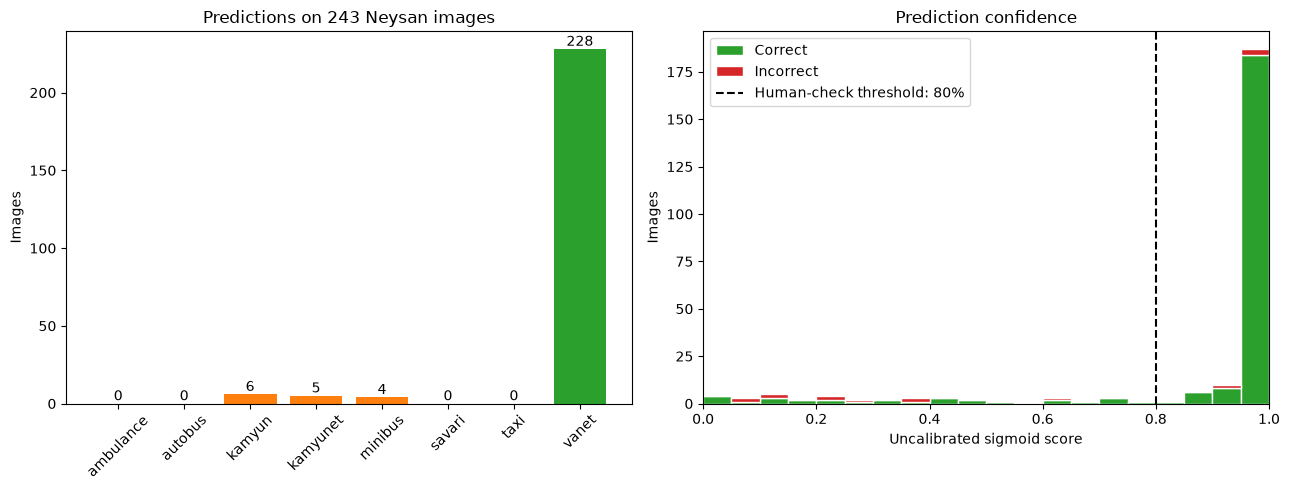

,Correct,Incorrect
Confidence < 80%,29,10
Confidence ≥ 80%,199,5


Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\neysan_experiment\neysan_test\neysan_results_summary.png


In [5]:
import matplotlib.pyplot as plt

results = pd.read_csv(EVALUATION_DIR / "predictions.csv")
correct_mask = (
    results["predicted_class"] == results["expected_class"]
)
review_mask = results["confidence"] < CONFIDENCE_THRESHOLD

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = (
    results["predicted_class"]
    .value_counts()
    .reindex(classes, fill_value=0)
)

bars = axes[0].bar(
    counts.index,
    counts.values,
    color=[
        "tab:green" if name == "vanet" else "tab:orange"
        for name in counts.index
    ],
)
axes[0].bar_label(bars)
axes[0].set_title("Predictions on 243 Neysan images")
axes[0].set_ylabel("Images")
axes[0].tick_params(axis="x", rotation=45)

bins = [i / 20 for i in range(21)]

axes[1].hist(
    [
        results.loc[correct_mask, "confidence"],
        results.loc[~correct_mask, "confidence"],
    ],
    bins=bins,
    label=["Correct", "Incorrect"],
    color=["tab:green", "tab:red"],
    stacked=True,
    edgecolor="white",
)
axes[1].axvline(
    CONFIDENCE_THRESHOLD,
    color="black",
    linestyle="--",
    label="Human-check threshold: 80%",
)
axes[1].set_title("Prediction confidence")
axes[1].set_xlabel("Uncalibrated sigmoid score")
axes[1].set_ylabel("Images")
axes[1].set_xlim(0, 1)
axes[1].legend()

fig.tight_layout()

figure_path = EVALUATION_DIR / "neysan_results_summary.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

review_summary = pd.DataFrame({
    "Correct": [
        int((review_mask & correct_mask).sum()),
        int((~review_mask & correct_mask).sum()),
    ],
    "Incorrect": [
        int((review_mask & ~correct_mask).sum()),
        int((~review_mask & ~correct_mask).sum()),
    ],
}, index=["Confidence < 80%", "Confidence ≥ 80%"])

review_summary.to_csv(
    EVALUATION_DIR / "confidence_review_summary.csv"
)

display(review_summary)
print("Figure saved:", figure_path)

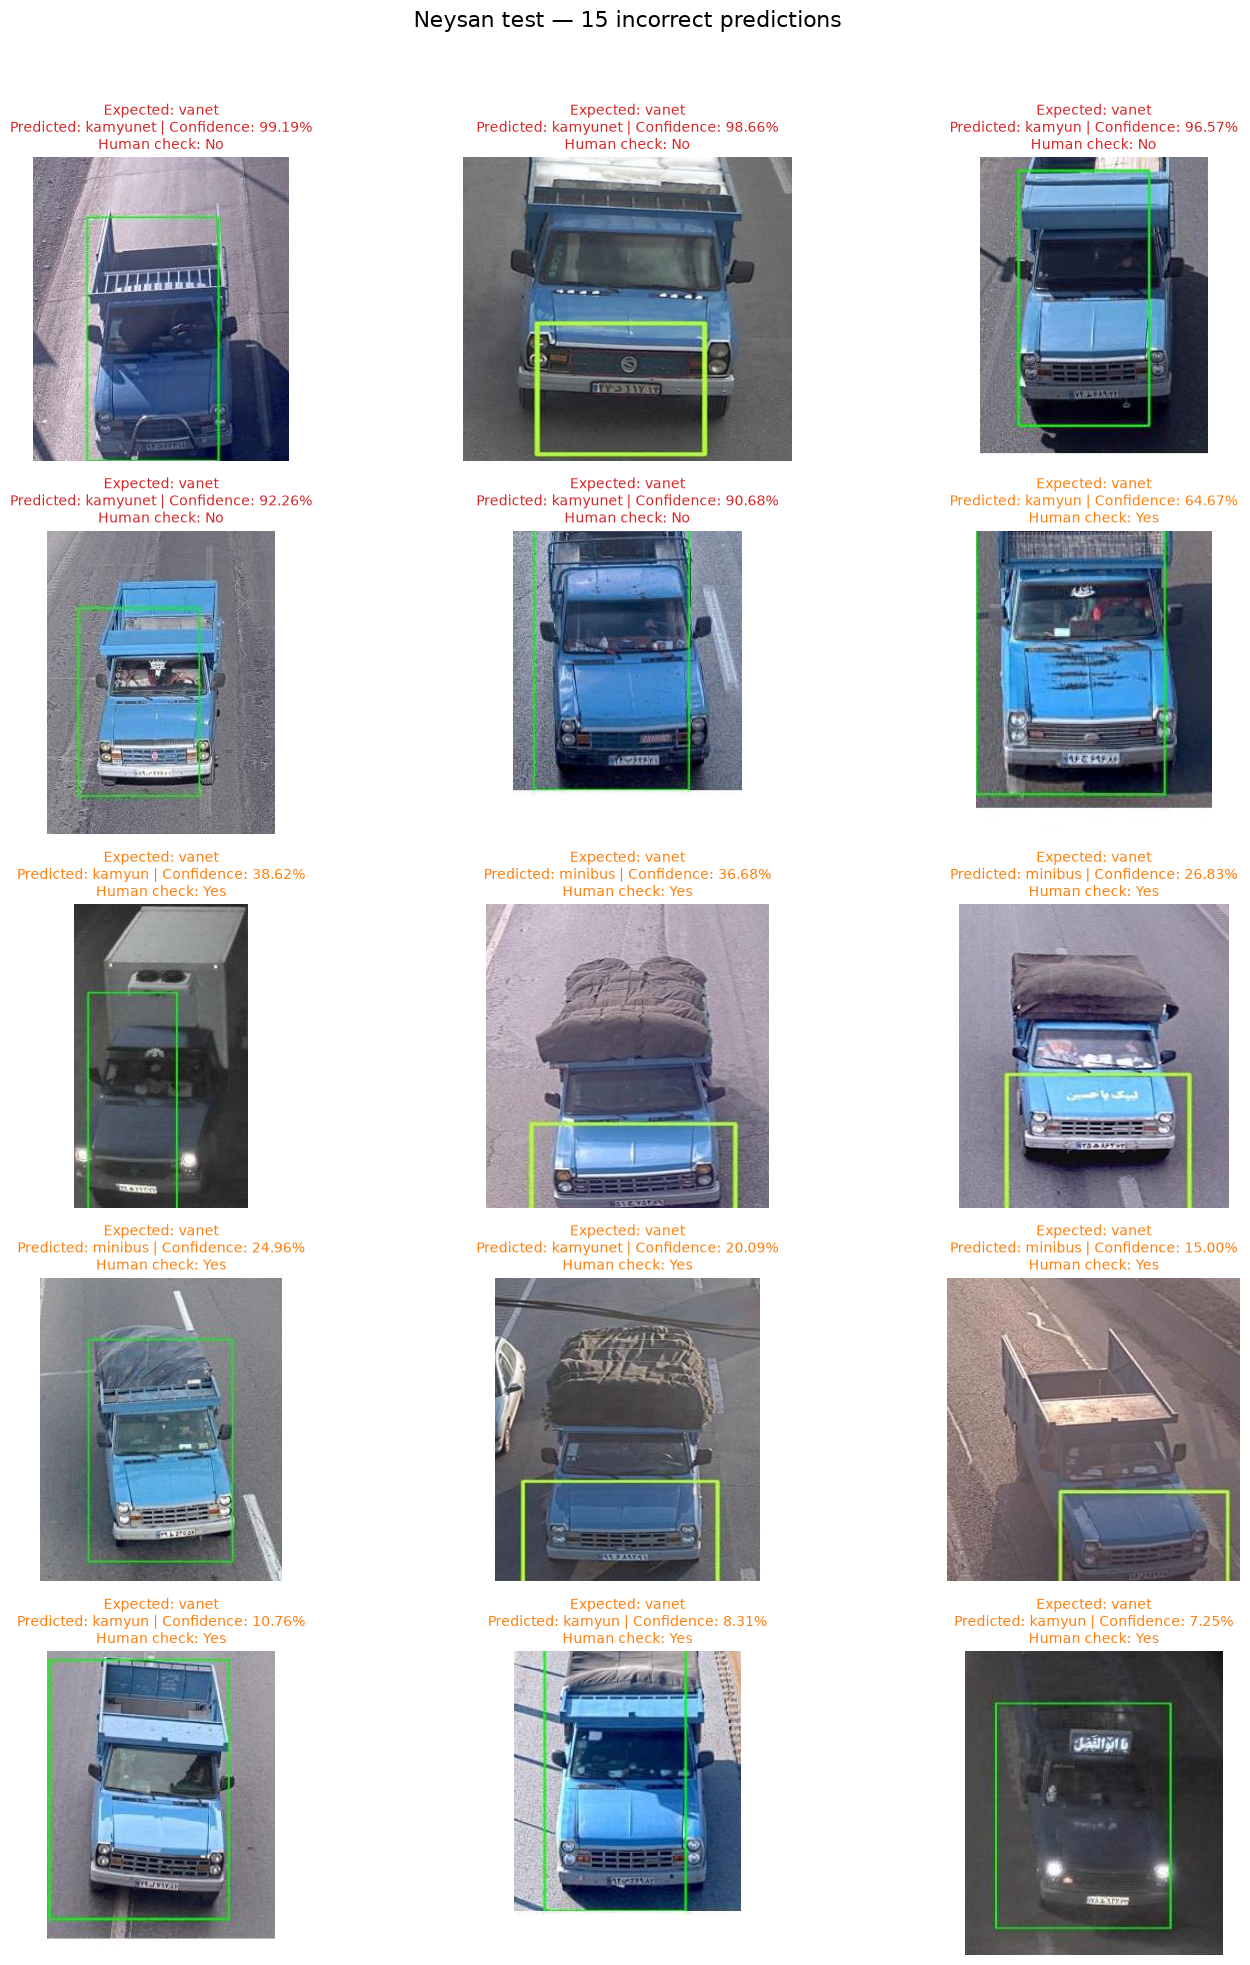

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\neysan_experiment\neysan_test\neysan_errors.png
Total errors: 15
Errors below 80% confidence: 10
Errors at or above 80% confidence: 5


In [8]:
from PIL import Image, ImageOps

results = pd.read_csv(EVALUATION_DIR / "predictions.csv")

errors_df = results[
    results["predicted_class"] != results["expected_class"]
].copy()

errors_df = errors_df.sort_values(
    "confidence", ascending=False
).reset_index(drop=True)

if errors_df.empty:
    print("No misclassified images.")
else:
    columns = 3
    rows = math.ceil(len(errors_df) / columns)

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(15, rows * 4),
        squeeze=False,
    )

    for ax in axes.flat:
        ax.axis("off")

    for ax, (_, row) in zip(axes.flat, errors_df.iterrows()):
        with Image.open(row["path"]) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            ax.imshow(image)

        needs_review = row["confidence"] < CONFIDENCE_THRESHOLD

        ax.set_title(
            f"Expected: {row['expected_class']}\n"
            f"Predicted: {row['predicted_class']} | "
            f"Confidence: {row['confidence'] * 100:.2f}%\n"
            f"Human check: {'Yes' if needs_review else 'No'}",
            fontsize=10,
            color="tab:orange" if needs_review else "tab:red",
        )

    fig.suptitle(
        f"Neysan test — {len(errors_df)} incorrect predictions",
        fontsize=16,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    error_figure_path = EVALUATION_DIR / "neysan_errors.png"
    fig.savefig(
        error_figure_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    print("Figure saved:", error_figure_path)
    print("Total errors:", len(errors_df))
    print(
        "Errors below 80% confidence:",
        int((errors_df["confidence"] < CONFIDENCE_THRESHOLD).sum()),
    )
    print(
        "Errors at or above 80% confidence:",
        int((errors_df["confidence"] >= CONFIDENCE_THRESHOLD).sum()),
    )